<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/glasslego/ml-deep-learning-study/blob/main/src/deep_learning_basic/02_mlp_basics.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩에서 실행하기</a>
  </td>
</table>

# MLP(Multi-Layer Perceptron) 기초 - 하이퍼파라미터 튜닝 실습

이 노트북에서는 딥러닝의 가장 기본적인 구조인 MLP(다층 퍼셉트론)를 구현하고, 다양한 하이퍼파라미터를 변경하면서 성능 변화를 관찰합니다.

In [ ]:
# PyTorch 임포트 (Google Colab T4 환경)
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 나눔고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 폰트 설정
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)  # 마이너스 기호 깨짐 방지

print(f"PyTorch 버전: {torch.__version__}")

# GPU 설정 (Google Colab T4 환경)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: {device}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA 버전: {torch.version.cuda}")
else:
    device = torch.device("cpu")
    print(f"Using device: {device}")

# 시드 설정 (재현 가능한 결과를 위해)
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

## 1. 데이터셋 생성 및 시각화

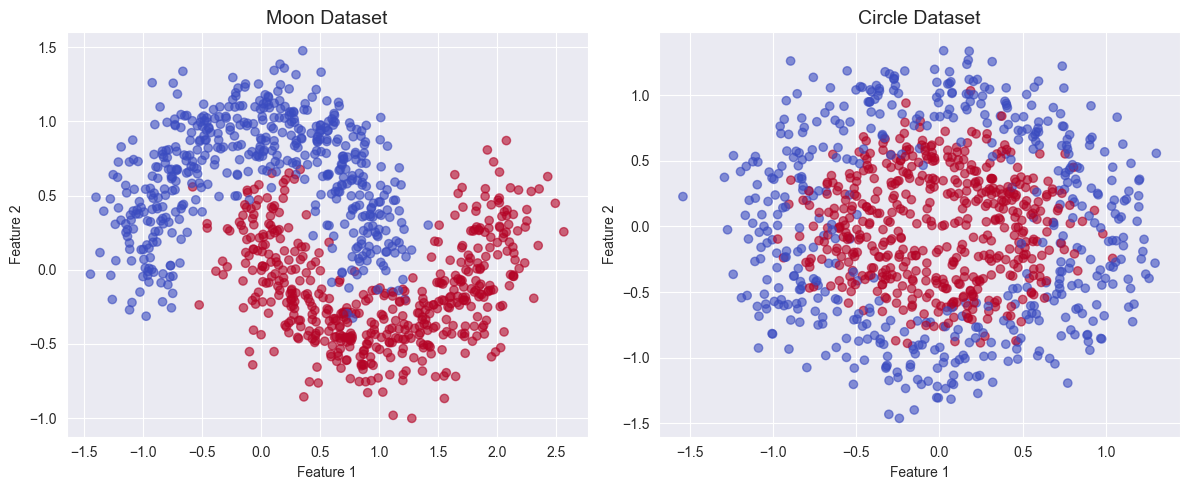

In [2]:
# 두 개의 다른 데이터셋 생성
n_samples = 1000

# Moon 데이터셋
X_moon, y_moon = make_moons(n_samples=n_samples, noise=0.2, random_state=42)

# Circle 데이터셋
X_circle, y_circle = make_circles(n_samples=n_samples, noise=0.2, factor=0.5, random_state=42)

# 데이터 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Moon 데이터셋 시각화
ax1.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='coolwarm', alpha=0.6)
ax1.set_title('Moon Dataset', fontsize=14)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')

# Circle 데이터셋 시각화
ax2.scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, cmap='coolwarm', alpha=0.6)
ax2.set_title('Circle Dataset', fontsize=14)
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

## 2. 데이터 전처리

In [3]:
def prepare_data(X, y):
    """
    데이터를 학습에 적합한 형태로 전처리합니다.
    """
    # 데이터 정규화
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 학습/테스트 데이터 분할
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    # PyTorch 텐서로 변환
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1)).to(device)
    y_test_tensor = torch.FloatTensor(y_test.reshape(-1, 1)).to(device)
    
    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor, scaler

# 두 데이터셋 전처리
X_train_moon, X_test_moon, y_train_moon, y_test_moon, scaler_moon = prepare_data(X_moon, y_moon)
X_train_circle, X_test_circle, y_train_circle, y_test_circle, scaler_circle = prepare_data(X_circle, y_circle)

print(f"Moon dataset - Train: {X_train_moon.shape}, Test: {X_test_moon.shape}")
print(f"Circle dataset - Train: {X_train_circle.shape}, Test: {X_test_circle.shape}")

Moon dataset - Train: torch.Size([800, 2]), Test: torch.Size([200, 2])
Circle dataset - Train: torch.Size([800, 2]), Test: torch.Size([200, 2])


## 3. 유연한 MLP 모델 정의

In [4]:
class FlexibleMLP(nn.Module):
    """
    다양한 하이퍼파라미터를 조정할 수 있는 유연한 MLP 모델
    """
    def __init__(self, input_dim=2, hidden_dims=[64, 32], output_dim=1, 
                 activation='relu', dropout_rate=0.0):
        super(FlexibleMLP, self).__init__()
        
        # 활성화 함수 선택
        activations = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
            'leaky_relu': nn.LeakyReLU(0.1)
        }
        self.activation = activations.get(activation, nn.ReLU())
        
        # 레이어 구성
        layers = []
        prev_dim = input_dim
        
        # 은닉층 구성
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(self.activation)
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        # 출력층
        layers.append(nn.Linear(prev_dim, output_dim))
        layers.append(nn.Sigmoid())  # 이진 분류를 위한 시그모이드
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

# 모델 테스트
test_model = FlexibleMLP(hidden_dims=[64, 32])
print("모델 구조:")
print(test_model)

모델 구조:
FlexibleMLP(
  (activation): ReLU()
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## 4. 학습 함수 정의

In [5]:
def train_model(model, X_train, y_train, X_test, y_test, 
                learning_rate=0.01, epochs=100, batch_size=32):
    """
    모델을 학습시키고 손실 기록을 반환합니다.
    """
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    
    n_batches = len(X_train) // batch_size
    
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        
        # 미니배치 학습
        indices = torch.randperm(len(X_train))
        for i in range(n_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            batch_indices = indices[start_idx:end_idx]
            
            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
        
        # 평가
        model.eval()
        with torch.no_grad():
            # 학습 데이터 평가
            train_outputs = model(X_train)
            train_loss = criterion(train_outputs, y_train)
            train_pred = (train_outputs > 0.5).float()
            train_accuracy = (train_pred == y_train).float().mean().item()
            
            # 테스트 데이터 평가
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            test_pred = (test_outputs > 0.5).float()
            test_accuracy = (test_pred == y_test).float().mean().item()
        
        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)
        
        if epoch % 20 == 0:
            print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, '
                  f'Train Acc: {train_accuracy:.4f}, Test Acc: {test_accuracy:.4f}')
    
    return {
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies
    }

## 5. 하이퍼파라미터 비교 실험 1: 은닉층 크기

In [6]:
# 다양한 은닉층 크기로 실험
hidden_layer_configs = [
    [16],           # 작은 단일 은닉층
    [64],           # 중간 단일 은닉층
    [128],          # 큰 단일 은닉층
    [64, 32],       # 2개 은닉층
    [128, 64, 32],  # 3개 은닉층 (깊은 네트워크)
]

results_hidden = {}

print("Moon 데이터셋에서 은닉층 크기 실험:")
print("=" * 50)

for config in hidden_layer_configs:
    config_name = str(config)
    print(f"\n은닉층 구조: {config_name}")
    
    model = FlexibleMLP(hidden_dims=config).to(device)
    results = train_model(model, X_train_moon, y_train_moon, 
                         X_test_moon, y_test_moon, epochs=100)
    results_hidden[config_name] = results

Moon 데이터셋에서 은닉층 크기 실험:

은닉층 구조: [16]


AttributeError: module 'torch.utils._pytree' has no attribute 'register_pytree_node'

In [ ]:
# 결과 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 손실 그래프
for config_name, results in results_hidden.items():
    ax1.plot(results['test_losses'], label=f'Hidden: {config_name}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Loss')
ax1.set_title('은닉층 크기별 테스트 손실 변화')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 정확도 그래프
for config_name, results in results_hidden.items():
    ax2.plot(results['test_accuracies'], label=f'Hidden: {config_name}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('은닉층 크기별 테스트 정확도 변화')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 하이퍼파라미터 비교 실험 2: 학습률

In [ ]:
# 다양한 학습률로 실험
learning_rates = [0.0001, 0.001, 0.01, 0.1]
results_lr = {}

print("학습률 실험:")
print("=" * 50)

for lr in learning_rates:
    print(f"\n학습률: {lr}")
    
    model = FlexibleMLP(hidden_dims=[64, 32]).to(device)
    results = train_model(model, X_train_moon, y_train_moon, 
                         X_test_moon, y_test_moon, 
                         learning_rate=lr, epochs=100)
    results_lr[str(lr)] = results

In [ ]:
# 학습률 결과 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 손실 그래프
for lr_name, results in results_lr.items():
    ax1.plot(results['test_losses'], label=f'LR: {lr_name}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Loss')
ax1.set_title('학습률별 테스트 손실 변화')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')  # 로그 스케일로 표시

# 정확도 그래프
for lr_name, results in results_lr.items():
    ax2.plot(results['test_accuracies'], label=f'LR: {lr_name}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('학습률별 테스트 정확도 변화')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 하이퍼파라미터 비교 실험 3: 활성화 함수

In [ ]:
# 다양한 활성화 함수로 실험
activations = ['relu', 'tanh', 'sigmoid', 'leaky_relu']
results_activation = {}

print("활성화 함수 실험:")
print("=" * 50)

for activation in activations:
    print(f"\n활성화 함수: {activation}")
    
    model = FlexibleMLP(hidden_dims=[64, 32], activation=activation).to(device)
    results = train_model(model, X_train_moon, y_train_moon, 
                         X_test_moon, y_test_moon, epochs=100)
    results_activation[activation] = results

In [ ]:
# 활성화 함수 결과 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 손실 그래프
for activation, results in results_activation.items():
    ax1.plot(results['test_losses'], label=f'{activation}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Loss')
ax1.set_title('활성화 함수별 테스트 손실 변화')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 정확도 그래프
for activation, results in results_activation.items():
    ax2.plot(results['test_accuracies'], label=f'{activation}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('활성화 함수별 테스트 정확도 변화')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 드롭아웃 효과 실험

In [ ]:
# 다양한 드롭아웃 비율로 실험
dropout_rates = [0.0, 0.2, 0.5, 0.7]
results_dropout = {}

print("드롭아웃 실험:")
print("=" * 50)

for dropout in dropout_rates:
    print(f"\n드롭아웃 비율: {dropout}")
    
    model = FlexibleMLP(hidden_dims=[128, 64, 32], dropout_rate=dropout).to(device)
    results = train_model(model, X_train_moon, y_train_moon, 
                         X_test_moon, y_test_moon, epochs=150)
    results_dropout[str(dropout)] = results

In [ ]:
# 드롭아웃 결과 시각화
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# 학습 손실
for dropout, results in results_dropout.items():
    ax1.plot(results['train_losses'], label=f'Dropout: {dropout}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss')
ax1.set_title('드롭아웃별 학습 손실')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 테스트 손실
for dropout, results in results_dropout.items():
    ax2.plot(results['test_losses'], label=f'Dropout: {dropout}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Loss')
ax2.set_title('드롭아웃별 테스트 손실')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 학습 정확도
for dropout, results in results_dropout.items():
    ax3.plot(results['train_accuracies'], label=f'Dropout: {dropout}')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Train Accuracy')
ax3.set_title('드롭아웃별 학습 정확도')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 테스트 정확도
for dropout, results in results_dropout.items():
    ax4.plot(results['test_accuracies'], label=f'Dropout: {dropout}')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Test Accuracy')
ax4.set_title('드롭아웃별 테스트 정확도')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 결정 경계 시각화

In [ ]:
def plot_decision_boundary(model, X, y, scaler, title="Decision Boundary"):
    """
    모델의 결정 경계를 시각화합니다.
    """
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # 격자 점들을 모델에 입력
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid_points)
    grid_tensor = torch.FloatTensor(grid_scaled).to(device)
    
    model.eval()
    with torch.no_grad():
        Z = model(grid_tensor).cpu().numpy()
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
    plt.colorbar(label='Prediction')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', 
                edgecolors='black', linewidth=1, s=50)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show()

# 최적 모델로 결정 경계 시각화
best_model = FlexibleMLP(hidden_dims=[64, 32], activation='relu').to(device)
train_model(best_model, X_train_moon, y_train_moon, 
            X_test_moon, y_test_moon, epochs=200)

plot_decision_boundary(best_model, X_moon, y_moon, scaler_moon, 
                      "Moon Dataset - Decision Boundary")

## 10. Circle 데이터셋에서 실험

In [ ]:
# Circle 데이터셋으로도 실험
print("Circle 데이터셋 실험:")
print("=" * 50)

# 다양한 설정으로 실험
configs = [
    {'name': 'Small Network', 'hidden': [16], 'lr': 0.01},
    {'name': 'Medium Network', 'hidden': [64, 32], 'lr': 0.01},
    {'name': 'Large Network', 'hidden': [128, 64, 32], 'lr': 0.01},
    {'name': 'Deep Network', 'hidden': [64, 64, 64, 64], 'lr': 0.001},
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, config in enumerate(configs):
    print(f"\n{config['name']} - Hidden: {config['hidden']}")
    
    model = FlexibleMLP(hidden_dims=config['hidden']).to(device)
    results = train_model(model, X_train_circle, y_train_circle,
                         X_test_circle, y_test_circle,
                         learning_rate=config['lr'], epochs=200)
    
    # 결정 경계 그리기
    h = 0.02
    x_min, x_max = X_circle[:, 0].min() - 0.5, X_circle[:, 0].max() + 0.5
    y_min, y_max = X_circle[:, 1].min() - 0.5, X_circle[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler_circle.transform(grid_points)
    grid_tensor = torch.FloatTensor(grid_scaled).to(device)
    
    model.eval()
    with torch.no_grad():
        Z = model(grid_tensor).cpu().numpy()
    Z = Z.reshape(xx.shape)
    
    ax = axes[i]
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
    ax.scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, cmap='RdBu',
               edgecolors='black', linewidth=1, s=30)
    ax.set_title(f"{config['name']}\nTest Acc: {results['test_accuracies'][-1]:.3f}")
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

## 11. 인터랙티브 하이퍼파라미터 튜닝 도구

In [ ]:
def interactive_mlp_training(hidden_layers="64,32", learning_rate=0.01, 
                           activation='relu', dropout=0.0, epochs=100,
                           dataset='moon'):
    """
    사용자가 직접 하이퍼파라미터를 조정하여 학습할 수 있는 함수
    """
    # 데이터셋 선택
    if dataset == 'moon':
        X_train, X_test = X_train_moon, X_test_moon
        y_train, y_test = y_train_moon, y_test_moon
        X_orig, y_orig = X_moon, y_moon
        scaler = scaler_moon
    else:
        X_train, X_test = X_train_circle, X_test_circle
        y_train, y_test = y_train_circle, y_test_circle
        X_orig, y_orig = X_circle, y_circle
        scaler = scaler_circle
    
    # 은닉층 파싱
    hidden_dims = [int(x.strip()) for x in hidden_layers.split(',')]
    
    # 모델 생성 및 학습
    print(f"\n설정된 하이퍼파라미터:")
    print(f"- 은닉층: {hidden_dims}")
    print(f"- 학습률: {learning_rate}")
    print(f"- 활성화 함수: {activation}")
    print(f"- 드롭아웃: {dropout}")
    print(f"- 에폭 수: {epochs}")
    print(f"- 데이터셋: {dataset}")
    print("\n학습 시작...")
    
    model = FlexibleMLP(hidden_dims=hidden_dims, activation=activation, 
                       dropout_rate=dropout).to(device)
    
    results = train_model(model, X_train, y_train, X_test, y_test,
                         learning_rate=learning_rate, epochs=epochs)
    
    # 결과 시각화
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # 손실 곡선
    ax1.plot(results['train_losses'], label='Train Loss')
    ax1.plot(results['test_losses'], label='Test Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('학습 곡선')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 정확도 곡선
    ax2.plot(results['train_accuracies'], label='Train Acc')
    ax2.plot(results['test_accuracies'], label='Test Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('정확도 변화')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 결정 경계
    h = 0.02
    x_min, x_max = X_orig[:, 0].min() - 0.5, X_orig[:, 0].max() + 0.5
    y_min, y_max = X_orig[:, 1].min() - 0.5, X_orig[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid_points)
    grid_tensor = torch.FloatTensor(grid_scaled).to(device)
    
    model.eval()
    with torch.no_grad():
        Z = model(grid_tensor).cpu().numpy()
    Z = Z.reshape(xx.shape)
    
    ax3.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
    ax3.scatter(X_orig[:, 0], X_orig[:, 1], c=y_orig, cmap='RdBu',
                edgecolors='black', linewidth=1, s=50)
    ax3.set_xlabel('Feature 1')
    ax3.set_ylabel('Feature 2')
    ax3.set_title('결정 경계')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n최종 결과:")
    print(f"- 학습 정확도: {results['train_accuracies'][-1]:.4f}")
    print(f"- 테스트 정확도: {results['test_accuracies'][-1]:.4f}")
    
    return model, results

# 예시 실행
model, results = interactive_mlp_training(
    hidden_layers="128,64,32",
    learning_rate=0.01,
    activation='relu',
    dropout=0.2,
    epochs=150,
    dataset='circle'
)

## 12. 하이퍼파라미터 튜닝 가이드

### 주요 하이퍼파라미터와 그 영향:

#### 1. **은닉층 크기와 깊이**
- **작은 네트워크**: 빠른 학습, 단순한 패턴 학습
- **큰 네트워크**: 복잡한 패턴 학습 가능, 과적합 위험
- **깊은 네트워크**: 더 추상적인 특징 학습, 학습 어려움 증가

#### 2. **학습률 (Learning Rate)**
- **너무 작음 (0.0001)**: 학습이 매우 느림
- **적절함 (0.001-0.01)**: 안정적인 학습
- **너무 큼 (0.1+)**: 불안정한 학습, 발산 가능성

#### 3. **활성화 함수**
- **ReLU**: 가장 일반적, 빠른 학습, 음수 부분 무시
- **Tanh**: 출력이 -1~1, 중심이 0
- **Sigmoid**: 출력이 0~1, 깊은 네트워크에서 기울기 소실
- **Leaky ReLU**: ReLU의 개선, 음수 부분도 약간의 기울기

#### 4. **드롭아웃**
- **0%**: 정규화 없음, 과적합 위험
- **20-50%**: 적절한 정규화
- **70%+**: 너무 강한 정규화, 학습 능력 저하

### 실험해볼 만한 설정들:

1. **단순한 데이터 (Moon)**:
   - `hidden_layers="32,16", learning_rate=0.01, activation='relu'`

2. **복잡한 데이터 (Circle)**:
   - `hidden_layers="128,64,32", learning_rate=0.001, activation='relu', dropout=0.3`

3. **과적합 방지**:
   - `hidden_layers="256,128,64", dropout=0.5`

위의 `interactive_mlp_training` 함수를 사용하여 다양한 설정을 실험해보세요!